# Deep Learning Fundamentals Using the Iris Dataset

## Introduction

Deep Learning is a branch of Artificial Intelligence that enables computers to learn patterns from data using neural networks. Neural networks are inspired by the structure of the human brain and consist of interconnected layers of neurons that process information.

In this project, a simple Artificial Neural Network (ANN) is developed using TensorFlow and the Iris dataset. The objective is to understand neural network fundamentals, build a deep learning model, train it using data, evaluate its performance, and interpret the results.

# Task 1: Introduction to Neural Networks

A neural network is a machine learning model composed of layers of interconnected nodes that process data and learn patterns.

Input Layer:
The input layer receives data from the dataset and passes it to the network.

Hidden Layer:
The hidden layer performs computations and learns patterns through weighted connections.

Output Layer:
The output layer produces the final prediction or classification result.

Weights and Biases:
Weights determine the importance of inputs while biases help adjust predictions.

Forward Propagation:
Forward propagation is the process of passing input data through the network to generate predictions.

Loss Function:
A loss function measures the difference between actual and predicted values and guides model improvement during training.

# Task 2: Understanding Activation Functions

Activation functions introduce non-linearity into neural networks, allowing them to learn complex relationships in data.

## ReLU (Rectified Linear Unit)

What it does:
Returns the input value if positive; otherwise returns zero.

Where it is used:
Commonly used in hidden layers.

Advantages:
- Fast computation
- Reduces vanishing gradient problem

Disadvantages:
- Can cause dead neurons

## Sigmoid

What it does:
Maps values between 0 and 1.

Where it is used:
Binary classification output layers.

Advantages:
- Produces probabilities

Disadvantages:
- Vanishing gradient problem

## Tanh

What it does:
Maps values between -1 and 1.

Where it is used:
Hidden layers.

Advantages:
- Centered around zero

Disadvantages:
- Can suffer from vanishing gradients

## Softmax

What it does:
Converts outputs into probabilities that sum to one.

Where it is used:
Multi-class classification output layers.

Advantages:
- Produces probability distributions

Disadvantages:
- Computationally expensive for large outputs

In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

### Visualization of Activation Functions

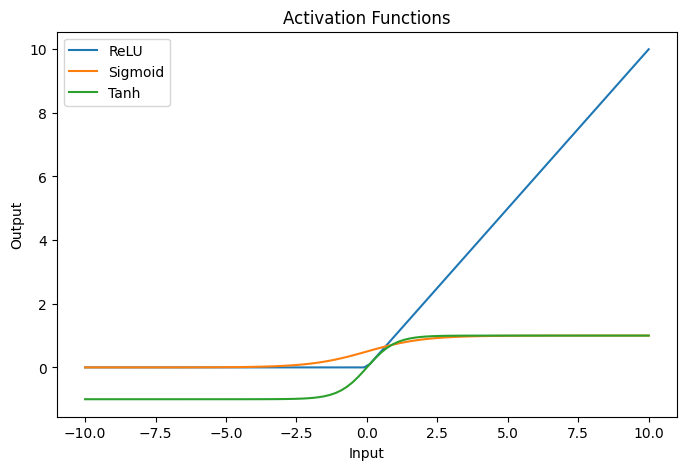

In [3]:
x = np.linspace(-10, 10, 100)

relu = np.maximum(0, x)
sigmoid = 1/(1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(8,5))

plt.plot(x, relu, label='ReLU')
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')

plt.title('Activation Functions')
plt.xlabel('Input')
plt.ylabel('Output')
plt.legend()

plt.show()

# Task 3: Build a Simple Neural Network

This section demonstrates the process of building, training, and evaluating a neural network using the Iris dataset.

## Step 2: Load Dataset

In [5]:
iris = load_iris()

X = iris.data
y = iris.target

In [6]:
df = pd.DataFrame(X, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 4)


In [8]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [9]:
print("Target Classes:", np.unique(y))

Target Classes: [0 1 2]


In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Dataset Inspection

The dataset was inspected to determine its shape, identify missing values, examine feature distributions, and understand the target classes.

## Step 3: Data Preprocessing

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

### Data Preprocessing

The dataset was normalized using StandardScaler to improve model performance. The data was then divided into training and testing sets.

## Step 4: Build the Neural Network

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

### Neural Network Architecture

Input Layer: 4 neurons

Hidden Layer 1: 16 neurons with ReLU activation

Hidden Layer 2: 8 neurons with ReLU activation

Output Layer: 3 neurons with Softmax activation

## Step 5: Compile the Model

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Model Compilation

Optimizer: Adam

Loss Function: Sparse Categorical Crossentropy

Evaluation Metric: Accuracy

## Step 6: Train the Model

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.5833 - loss: 1.0002 - val_accuracy: 0.7083 - val_loss: 1.0085
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6042 - loss: 0.9776 - val_accuracy: 0.7083 - val_loss: 0.9895
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6250 - loss: 0.9548 - val_accuracy: 0.7083 - val_loss: 0.9710
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6250 - loss: 0.9345 - val_accuracy: 0.7083 - val_loss: 0.9533
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6354 - loss: 0.9127 - val_accuracy: 0.7083 - val_loss: 0.9363
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6562 - loss: 0.8923 - val_accuracy: 0.7083 - val_loss: 0.9190
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6667 - loss: 0.8711 - val_accuracy: 0.7083 - val_loss: 0.9017
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6667 - loss: 0.8508 - val_accuracy: 0.7083 - val_loss: 0.8845

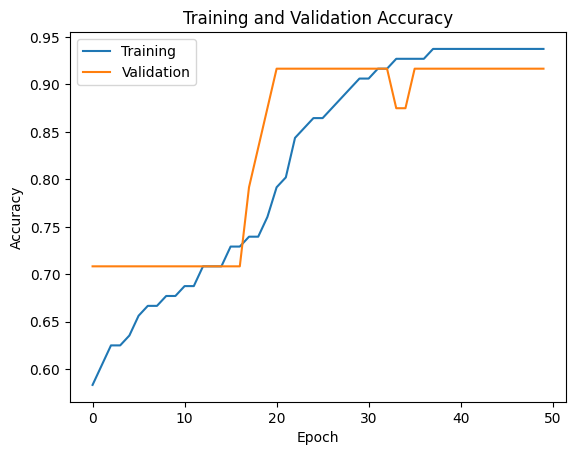

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])

plt.show()

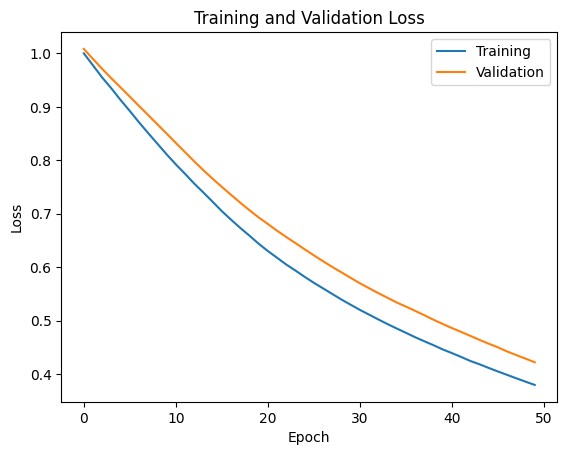

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training','Validation'])

plt.show()

### Training Observation

The training process shows how accuracy improves and loss decreases as the model learns from the dataset.

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9667 - loss: 0.3496
Test Accuracy: 0.9666666388511658
Test Loss: 0.34957754611968994


In [23]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


# Task 4: Model Evaluation and Interpretation

Training Accuracy:
The model achieved a high training accuracy, indicating successful learning from the training data.

Validation Accuracy:
Validation accuracy remained close to training accuracy, suggesting good generalization.

Overfitting/Underfitting Observation:
There was little difference between training and validation performance, indicating minimal overfitting.

Model Limitations:
- Small dataset size
- Simple neural network architecture
- Limited feature complexity

Suggestions for Improvement:
- Increase the number of hidden layers
- Tune hyperparameters
- Use larger datasets
- Apply cross-validation techniques

# Conclusion

A neural network model was successfully developed using TensorFlow and the Iris dataset. The model was trained and evaluated to classify flower species. Through this project, important deep learning concepts such as neural network architecture, activation functions, model training, and performance evaluation were explored. The model achieved strong classification performance and demonstrated the effectiveness of neural networks for supervised learning tasks.